# 01 - Data Understanding

## Price Intelligence Platform

Ce notebook correspond a la premiere phase du travail Data Analyst : comprendre les donnees disponibles avant le nettoyage et les tests statistiques.

**Objectif :** analyser la structure du dataset, la couverture des plateformes/catégories, les valeurs manquantes, la distribution des prix et les premiers outliers.


## Source officielle mise à jour

Après le dernier merge, la source officielle des données est BigQuery :

```text
price-intelligence-495411.price_intelligence.products
```

Le notebook charge BigQuery en priorité. Si l'accès BigQuery n'est pas disponible dans Anaconda, il utilise un snapshot CSV exporté dans `outputs/raw_data/bigquery_products_export.csv`. Le fallback local JSON ne doit servir qu'au développement offline.


## BigQuery obligatoire

Ce notebook ne doit plus utiliser les anciens JSON locaux. La source officielle est BigQuery :

```text
price-intelligence-495411.price_intelligence.products
```

Si BigQuery n’est pas accessible depuis Anaconda, exporte la table BigQuery en CSV et place le fichier ici :

```text
C:\Users\Admin\Desktop\data-analysis\outputs\raw_data\bigquery_products_export.csv
```

Le notebook utilisera ce snapshot BigQuery. Sans accès BigQuery et sans export CSV, il s’arrêtera au lieu de reprendre les anciennes données locales.


## 1. Contexte du projet

Le projet est une plateforme de veille tarifaire e-commerce. Les données sont collectées depuis plusieurs plateformes, puis stockées et préparées pour l'analyse.

Architecture globale :

```text
Scraping -> Bigtable -> BigQuery / dbt -> Python Analytics -> Dashboard / Rapport
```

Dans ce notebook, on ne nettoie pas encore les données. On observe et on documente les problèmes à traiter dans la phase suivante.

## 2. Imports et configuration

In [ ]:
from pathlib import Path
import sys

def find_analytics_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    candidates += [candidate / "analytics" for candidate in candidates]
    for candidate in candidates:
        if (candidate / "price_analysis.py").exists() and (candidate / "notebooks").exists():
            return candidate.resolve()
    raise FileNotFoundError("Impossible de trouver le dossier analytics. Ouvre le notebook depuis le repo price-intelligence ou analytics/notebooks.")

DATA_ANALYSIS_DIR = find_analytics_root()
PROJECT_ROOT = DATA_ANALYSIS_DIR.parent

if str(DATA_ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(DATA_ANALYSIS_DIR))

print("Dossier analytics :", DATA_ANALYSIS_DIR)
print("Dossier projet :", PROJECT_ROOT)


## 3. Configuration de l'auto-sauvegarde

In [2]:
OUTPUTS_DIR = DATA_ANALYSIS_DIR / "outputs"
OUTPUT_TABLES = OUTPUTS_DIR / "tables"
OUTPUT_FIGURES = OUTPUTS_DIR / "figures"

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

AUTO_SAVE = True

print("Auto-sauvegarde activée :", AUTO_SAVE)
print("Dossier des tableaux :", OUTPUT_TABLES)
print("Dossier des graphiques :", OUTPUT_FIGURES)

Auto-sauvegarde activée : True
Dossier des tableaux : C:\Users\Admin\Desktop\data-analysis\outputs\tables
Dossier des graphiques : C:\Users\Admin\Desktop\data-analysis\outputs\figures


In [3]:

EXPECTED_MIN_RAW_ROWS = 20000
EXPECTED_STORE = "sport-direct"
EXPECTED_MAX_NULL_PRICE = 500

def assert_official_bigquery_data(raw_df, cleaned_df=None, source=None):
    stores = set(raw_df.get("store", pd.Series(dtype="object")).dropna().astype(str).str.lower())
    null_price = raw_df["current_price"].isna().sum() if "current_price" in raw_df.columns else None
    if source is not None and source != "bigquery_live":
        raise ValueError(f"Source invalide: {source}. Le notebook doit utiliser BigQuery live, pas un ancien export/local.")
    if len(raw_df) < EXPECTED_MIN_RAW_ROWS:
        raise ValueError(f"Dataset trop petit ({len(raw_df)} lignes). Anciennes donnees detectees: recharge depuis BigQuery live.")
    if EXPECTED_STORE not in stores:
        raise ValueError(f"Store {EXPECTED_STORE} absent. Anciennes donnees detectees ou notebook non relance depuis BigQuery.")
    if null_price is not None and null_price > EXPECTED_MAX_NULL_PRICE:
        raise ValueError(f"Trop de prix null ({null_price}). Verifie la table BigQuery source.")
    if cleaned_df is not None and len(cleaned_df) < 15000:
        raise ValueError(f"Dataset nettoye trop petit ({len(cleaned_df)} lignes). Relance 02_data_cleaning.ipynb avec BigQuery live.")


## 4. Chargement des données

On charge les fichiers JSON locaux du projet `price-intelligence`. Plus tard, la même logique pourra être reliée à BigQuery.

In [4]:
# Securite : BigQuery live obligatoire pour eviter les anciennes donnees
DATA_SOURCE = "bigquery"
BQ_TABLE = "price-intelligence-495411.price_intelligence.products"
RAW_EXPORT_PATH = DATA_ANALYSIS_DIR / "outputs" / "raw_data" / "bigquery_products_export.csv"

raw_rows, effective_source = pa.load_project_rows(
    source=DATA_SOURCE,
    table_id=BQ_TABLE,
    project_root=PROJECT_ROOT,
    export_path=RAW_EXPORT_PATH,
    allow_export_fallback=False,
    allow_local_fallback=False,
)
raw_df = pd.DataFrame(raw_rows)
rows = pa.normalize_rows(raw_rows)
df = pd.DataFrame(rows)

assert_official_bigquery_data(raw_df, df, effective_source)

print("Source utilisee :", effective_source)
print("Table BigQuery officielle :", BQ_TABLE)
print("Nombre total de lignes brutes chargees :", len(raw_rows))
print("Nombre de lignes valides apres validation du prix :", len(df))
print("Lignes brutes avec name null :", raw_df["name"].isna().sum() if "name" in raw_df.columns else "colonne absente")
print("Lignes brutes avec current_price null :", raw_df["current_price"].isna().sum() if "current_price" in raw_df.columns else "colonne absente")
print("Plateformes detectees :", sorted(raw_df["store"].dropna().astype(str).str.lower().unique()) if "store" in raw_df.columns else "colonne absente")

df.head()


Source utilisee : bigquery_live
Table BigQuery officielle : price-intelligence-495411.price_intelligence.products
Nombre total de lignes brutes chargees : 23358
Nombre de lignes valides apres validation du prix : 23166
Lignes brutes avec name null : 192
Lignes brutes avec current_price null : 192
Plateformes detectees : ['ebay', 'jumia', 'sport-direct', 'unknown']


,store,category,name,price,price_before_discount,discount,stars,availability,scraped_at
0,ebay,unknown,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,915.57,NaN,NaN,5.0,In Stock,2026-05-15T22:09:41.674252
1,ebay,unknown,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,915.57,NaN,NaN,5.0,In Stock,2026-05-15T22:09:41.674252
2,ebay,gym,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,915.57,NaN,NaN,5.0,In Stock,2026-05-16T13:11:38.818884
3,ebay,gym,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,915.57,NaN,NaN,5.0,In Stock,2026-05-16T13:11:38.818884
4,ebay,gym,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,915.57,NaN,NaN,5.0,In Stock,2026-05-16T13:11:38.818884


## 5. Dimensions et colonnes du dataset

In [5]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre de lignes : 23166
Nombre de colonnes : 9


In [6]:
print("Colonnes disponibles :")
df.columns.tolist()

Colonnes disponibles :


['store',
 'category',
 'name',
 'price',
 'price_before_discount',
 'discount',
 'stars',
 'availability',
 'scraped_at']

## 6. Types des données et aperçu

In [7]:
print("Informations sur les types de données :")
df.info()

Informations sur les types de données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23166 entries, 0 to 23165
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   store                  23166 non-null  object 
 1   category               23166 non-null  object 
 2   name                   23166 non-null  object 
 3   price                  23166 non-null  float64
 4   price_before_discount  6882 non-null   float64
 5   discount               6882 non-null   float64
 6   stars                  23166 non-null  float64
 7   availability           23166 non-null  object 
 8   scraped_at             23166 non-null  object 
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


In [8]:
print("Aperçu aléatoire de 10 produits :")
df.sample(10, random_state=42)

Aperçu aléatoire de 10 produits :


,store,category,name,price,price_before_discount,discount,stars,availability,scraped_at
8351,ebay,combat-sports,MMA Leg Foot Guards Muay Thai Shin Instep Pads...,356.03,NaN,NaN,0.0,In Stock,2026-05-15T22:12:13.284601
13875,jumia,football,"Ballon de Football Marocain, Design Drapeau du...",49.00,80.00,39.0,0.0,-,2026-05-17T17:29:39.314283
7920,ebay,combat-sports,Cleto Reyes Boxing Gloves Velcroooo Strap Spar...,1110.00,NaN,NaN,0.0,In Stock,2026-05-17T15:12:32.831883
4178,ebay,basketball,New Balance Kawhi IV 4 Basketball Shoes Carbon...,532.71,NaN,NaN,0.0,In Stock,2026-05-16T13:07:58.805265
6913,ebay,combat-sports,Intelliguard Bruxism Night Sleep Aid Mouthpiec...,184.91,NaN,NaN,0.0,In Stock,2026-05-16T13:13:28.899619
9276,ebay,football,Adidas milano champions league 2016 official m...,666.00,NaN,NaN,0.0,In Stock,2026-05-17T15:09:18.770106
22565,sport-direct,basketball,Men's TATUM Basketball Trainers,793.75,1443.18,45.0,0.0,In Stock,2026-05-20T13:00:36.528062
6631,ebay,combat-sports,MYTRA Leather Shin pads Shin Guards Kickboxing...,353.26,NaN,NaN,0.0,In Stock,2026-05-15T22:12:13.300473
4954,ebay,combat-sports,Keystone 9598420 Pro-Form Mouthguard Laminates...,767.66,NaN,NaN,0.0,In Stock,2026-05-15T22:11:45.408094
18718,sport-direct,football,Predator League Fold-Over Tongue Firm Ground F...,562.50,1022.73,45.0,0.0,In Stock,2026-05-17T17:30:17.967049


In [9]:
print("Résumé descriptif des données :")
df.describe(include="all").T

Résumé descriptif des données :


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
store,23166,3,ebay,13363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,23166,7,combat-sports,5495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,23166,3569,Molten Volleyball- V5M2700,79,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,23166.0,NaN,NaN,NaN,488.469998,805.561693,9.0,129.31,269.0,559.0,35612.5
price_before_discount,6882.0,NaN,NaN,NaN,443.388503,428.161912,35.0,180.0,299.0,520.0,3000.0
discount,6882.0,NaN,NaN,NaN,36.74179,17.379561,1.0,25.0,36.0,49.0,90.0
stars,23166.0,NaN,NaN,NaN,0.524225,1.405734,0.0,0.0,0.0,0.0,5.0
availability,23166,2,In Stock,16308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scraped_at,23166,13030,2026-05-16T13:11:09.884008,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Analyse des valeurs manquantes

In [10]:
missing = df.isna().sum().reset_index()
missing.columns = ["colonne", "nombre_valeurs_manquantes"]
missing["taux_valeurs_manquantes"] = missing["nombre_valeurs_manquantes"] / len(df)

print("Valeurs manquantes par colonne :")
missing.sort_values("taux_valeurs_manquantes", ascending=False)

Valeurs manquantes par colonne :


,colonne,nombre_valeurs_manquantes,taux_valeurs_manquantes
4,price_before_discount,16284,0.702927
5,discount,16284,0.702927
0,store,0,0.000000
2,name,0,0.000000
1,category,0,0.000000
3,price,0,0.000000
6,stars,0,0.000000
7,availability,0,0.000000
8,scraped_at,0,0.000000


## 8. Couverture par plateforme

In [11]:
store_counts = df["store"].value_counts().reset_index()
store_counts.columns = ["plateforme", "nombre_produits"]

print("Nombre de produits par plateforme :")
store_counts

Nombre de produits par plateforme :


,plateforme,nombre_produits
0,ebay,13363
1,jumia,6858
2,sport-direct,2945


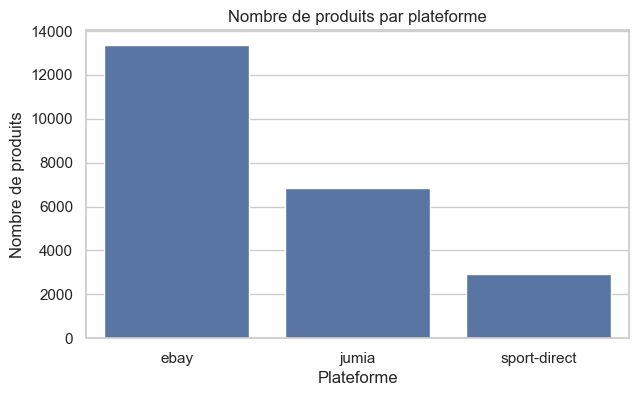

In [12]:
plt.figure(figsize=(7, 4))
sns.barplot(data=store_counts, x="plateforme", y="nombre_produits")
plt.title("Nombre de produits par plateforme")
plt.xlabel("Plateforme")
plt.ylabel("Nombre de produits")

if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "01_nombre_produits_par_plateforme.png", dpi=150, bbox_inches="tight")

plt.show()

## 9. Couverture par catégorie

In [13]:
category_counts = df["category"].value_counts().reset_index()
category_counts.columns = ["categorie", "nombre_produits"]

print("Nombre de produits par catégorie :")
category_counts

Nombre de produits par catégorie :


,categorie,nombre_produits
0,combat-sports,5495
1,football,4173
2,gym,3388
3,unknown,3210
4,basketball,3011
5,volleyball,2040
6,racket-sports,1849


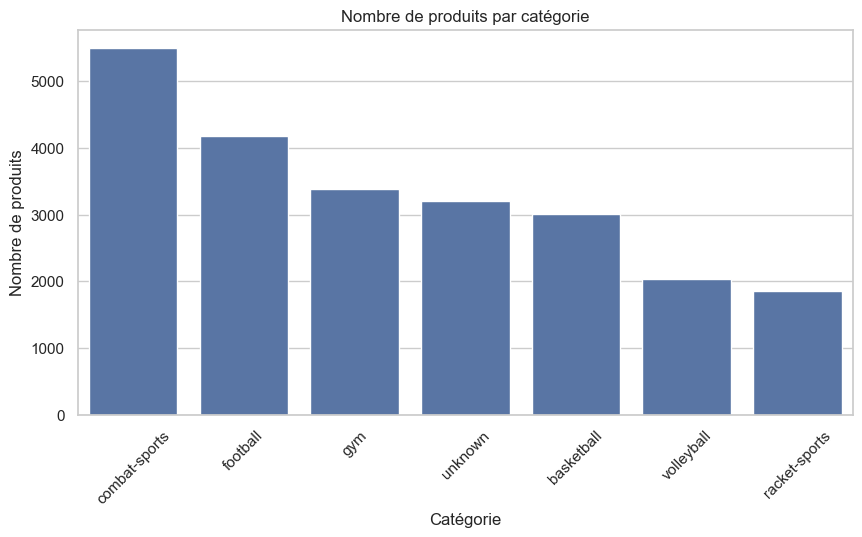

In [14]:
plt.figure(figsize=(10, 5))
sns.barplot(data=category_counts, x="categorie", y="nombre_produits")
plt.title("Nombre de produits par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de produits")
plt.xticks(rotation=45)

if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "01_nombre_produits_par_categorie.png", dpi=150, bbox_inches="tight")

plt.show()

## 10. Compréhension initiale des prix

In [15]:
print("Résumé statistique de la variable prix :")
df["price"].describe()

Résumé statistique de la variable prix :


count    23166.000000
mean       488.469998
std        805.561693
min          9.000000
25%        129.310000
50%        269.000000
75%        559.000000
max      35612.500000
Name: price, dtype: float64

In [16]:
price_by_store = df.groupby("store")["price"].agg(
    nombre_produits="count",
    prix_moyen="mean",
    prix_median="median",
    prix_minimum="min",
    prix_maximum="max",
    ecart_type="std"
).reset_index()

price_by_store = price_by_store.rename(columns={"store": "plateforme"})

print("Statistiques des prix par plateforme :")
price_by_store

Statistiques des prix par plateforme :


,plateforme,nombre_produits,prix_moyen,prix_median,prix_minimum,prix_maximum,ecart_type
0,ebay,13363,632.802495,356.03,9.16,35612.5,1001.178529
1,jumia,6858,233.308179,178.99,9.00,1591.0,224.318263
2,sport-direct,2945,427.751698,287.38,31.25,5250.0,435.424074


In [17]:
price_by_category = df.groupby("category")["price"].agg(
    nombre_produits="count",
    prix_moyen="mean",
    prix_median="median",
    prix_minimum="min",
    prix_maximum="max",
    ecart_type="std"
).reset_index()

price_by_category = price_by_category.rename(columns={"category": "categorie"})

print("Statistiques des prix par catégorie :")
price_by_category

Statistiques des prix par catégorie :


,categorie,nombre_produits,prix_moyen,prix_median,prix_minimum,prix_maximum,ecart_type
0,basketball,3011,450.354298,213.58,9.16,17527.73,831.870085
1,combat-sports,5495,337.942790,190.44,9.00,6659.91,443.851417
2,football,4173,547.749530,312.38,9.16,9249.91,865.274114
3,gym,3388,349.634324,299.00,53.74,7862.50,352.335380
4,racket-sports,1849,722.707150,307.56,18.79,7347.37,925.613273
5,unknown,3210,699.273794,374.53,9.16,35612.50,1339.673378
6,volleyball,2040,515.494745,349.00,9.16,6012.41,507.971402


## 11. Produits les plus chers et premiers outliers

In [18]:
top_expensive = df.sort_values("price", ascending=False)[
    ["store", "category", "price", "name"]
].head(15)

top_expensive = top_expensive.rename(columns={
    "store": "plateforme",
    "category": "categorie",
    "price": "prix",
    "name": "nom_produit"
})

print("Top 15 des produits les plus chers :")
top_expensive

Top 15 des produits les plus chers :


,plateforme,categorie,prix,nom_produit
10159,ebay,unknown,35612.50,​1970/73 NY Knicks Championship Autographed Ba...
10160,ebay,unknown,35612.50,​1970/73 NY Knicks Championship Autographed Ba...
21598,ebay,basketball,17527.73,Size 10 - Jordan 1 Retro OG x Off-White High C...
21192,ebay,basketball,14032.25,DM7866-140 Travis Scott fragment design Nike A...
6044,ebay,unknown,11562.50,Nike Air Jordan 1 Low OG SP Travis Scott Rever...
6045,ebay,unknown,11562.50,Nike Air Jordan 1 Low OG SP Travis Scott Rever...
404,ebay,football,9249.91,Nike Tiempo Legend VI 6 Elite Totti x Roma Gol...
1617,ebay,basketball,9249.91,NBA Victor Wembenyama Autographed Basketball W...
4459,ebay,basketball,8325.00,Tyrese Haliburton Signed & Multi-Inscribed Wil...
6361,ebay,football,8313.99,Zinedine Zidane Signed Adidas Soccer Ball Real...


## 12. Remises, notes et disponibilité

In [19]:
print("Résumé statistique des remises :")
df["discount"].describe()

Résumé statistique des remises :


count    6882.000000
mean       36.741790
std        17.379561
min         1.000000
25%        25.000000
50%        36.000000
75%        49.000000
max        90.000000
Name: discount, dtype: float64

In [20]:
top_discounts = df.dropna(subset=["discount"]).sort_values("discount", ascending=False)[
    ["store", "category", "discount", "price", "name"]
].head(10)

top_discounts = top_discounts.rename(columns={
    "store": "plateforme",
    "category": "categorie",
    "discount": "remise",
    "price": "prix",
    "name": "nom_produit"
})

print("Top 10 des plus grandes remises :")
top_discounts

Top 10 des plus grandes remises :


,plateforme,categorie,remise,prix,nom_produit
12861,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
12862,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
12863,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
12864,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
12859,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
12857,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
12869,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
12865,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
12866,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
12867,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M


In [21]:
print("Résumé statistique des notes clients :")
df["stars"].describe()

Résumé statistique des notes clients :


count    23166.000000
mean         0.524225
std          1.405734
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          5.000000
Name: stars, dtype: float64

In [22]:
print("Répartition des disponibilités :")
df["availability"].value_counts()

Répartition des disponibilités :


availability
In Stock    16308
-            6858
Name: count, dtype: int64

## 13. Sauvegarde automatique des outputs

In [23]:
if AUTO_SAVE:
    missing.to_csv(OUTPUT_TABLES / "01_valeurs_manquantes.csv", index=False)
    store_counts.to_csv(OUTPUT_TABLES / "01_nombre_produits_par_plateforme.csv", index=False)
    category_counts.to_csv(OUTPUT_TABLES / "01_nombre_produits_par_categorie.csv", index=False)
    price_by_store.to_csv(OUTPUT_TABLES / "01_prix_par_plateforme.csv", index=False)
    price_by_category.to_csv(OUTPUT_TABLES / "01_prix_par_categorie.csv", index=False)
    top_expensive.to_csv(OUTPUT_TABLES / "01_top_produits_plus_chers.csv", index=False)
    top_discounts.to_csv(OUTPUT_TABLES / "01_top_remises.csv", index=False)

    print("Auto-sauvegarde terminée.")
    print("Tableaux sauvegardés dans :", OUTPUT_TABLES)
    print("Graphiques sauvegardés dans :", OUTPUT_FIGURES)
else:
    print("Auto-sauvegarde désactivée.")

Auto-sauvegarde terminée.
Tableaux sauvegardés dans : C:\Users\Admin\Desktop\data-analysis\outputs\tables
Graphiques sauvegardés dans : C:\Users\Admin\Desktop\data-analysis\outputs\figures


## 15. Conclusion - Data Understanding

Premières observations à compléter après exécution du notebook :

- Le dataset contient des milliers de produits issus de plusieurs plateformes.
- Les plateformes disponibles sont eBay, Jumia et Walmart.
- Les catégories principales sont basketball, football, gym, combat-sports, volleyball et racket-sports.
- La colonne prix est exploitable après conversion numérique.
- Certaines colonnes comme les remises et les notes peuvent contenir des valeurs manquantes.
- La distribution des prix contient des outliers importants, surtout sur eBay.
- La médiane sera probablement plus fiable que la moyenne pour comparer les plateformes.
- La prochaine phase sera le nettoyage des données : valeurs manquantes, outliers, types et standardisation.